# Logistic Regression Modeling — Prediksi Risiko Dropout Mahasiswa

Notebook ini dipakai untuk:
1. membaca data hasil preprocessing,
2. melatih **Logistic Regression**,
3. mengevaluasi model,
4. menyimpan artefak model dan metrik.

> Asumsi:
> - file hasil preprocessing sudah ada di `/kaggle/working/data/processed/`
> - target biner adalah kolom `dropout_risk`


In [4]:
import os
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

## 1. Siapkan folder output

In [5]:
os.makedirs('/kaggle/working/models', exist_ok=True)
os.makedirs('/kaggle/working/figures', exist_ok=True)
os.makedirs('/kaggle/working/data/processed', exist_ok=True)

print('Folder output siap.')

Folder output siap.


## 2. Load data processed

In [6]:
train_path = '/kaggle/input/datasets/muhammadzackyrachim/modelin/train.csv'
test_path  = '/kaggle/input/datasets/muhammadzackyrachim/modelin/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
display(train_df.head())

Train shape: (3539, 38)
Test shape : (885, 38)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,dropout_risk
0,1,1,1,9147,1,1,130.0,1,38,37,...,5,5,1,12.000000,0,7.6,2.6,0.32,Dropout,1
1,1,1,1,9853,1,1,129.0,1,38,37,...,6,10,4,11.500000,0,7.6,2.6,0.32,Dropout,1
2,2,39,1,9991,0,1,140.0,1,37,37,...,5,9,2,11.000000,0,12.7,3.7,-1.70,Dropout,1
3,1,17,2,9670,1,1,129.0,1,19,19,...,6,10,5,13.125000,0,10.8,1.4,1.74,Dropout,1
4,1,1,3,9085,1,1,138.0,1,1,1,...,6,12,6,13.833333,0,8.9,1.4,3.51,Graduate,0


## 3. Pisahkan fitur dan target

In [7]:
TARGET_COL = 'dropout_risk'

drop_cols = [TARGET_COL]
if 'Target' in train_df.columns:
    drop_cols.append('Target')

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[TARGET_COL]

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('Distribusi y_train:')
print(y_train.value_counts())

X_train: (3539, 36)
X_test : (885, 36)
Distribusi y_train:
dropout_risk
0    2402
1    1137
Name: count, dtype: int64


## 4. Buat pipeline preprocessing + Logistic Regression

In [8]:
numeric_features = X_train.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='drop'
)

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

logreg_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Marital status',
                                                   'Application mode',
                                                   'Application order',
                                                   'Course',
                                                   'Daytime/evening '
                                                   'attendance\t',
                                                   'Previous qualification',
                                                   'Previous qualification '
                                                   '(grade)',
                                                   'Nacionality',
                                                   "Mother's qualification...
                                                   'Curricular units 1st sem '
                                                   '(evaluations)',
                                                   'Curricular units 1st sem '
                                                   '(approved)',
                                                   'Curricular units 1st sem '
                                                   '(grade)',
                                                   'Curricular units 1st sem '
                                                   '(without evaluations)',
                                                   'Curricular units 2nd sem '
                                                   '(credited)',
                                                   'Curricular units 2nd sem '
                                                   '(enrolled)',
                                                   'Curricular units 2nd sem '
                                                   '(evaluations)', ...])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

## 5. Training model

In [9]:
logreg_pipeline.fit(X_train, y_train)
print('Training Logistic Regression selesai.')

Training Logistic Regression selesai.


## 6. Prediksi & evaluasi

In [10]:
y_pred = logreg_pipeline.predict(X_test)
y_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

metrics = {
    'model_name': 'Logistic Regression',
    'accuracy': float(accuracy_score(y_test, y_pred)),
    'precision': float(precision_score(y_test, y_pred)),
    'recall': float(recall_score(y_test, y_pred)),
    'f1_score': float(f1_score(y_test, y_pred)),
    'roc_auc': float(roc_auc_score(y_test, y_proba))
}

metrics

{'model_name': 'Logistic Regression',
 'accuracy': 0.8734463276836159,
 'precision': 0.7866666666666666,
 'recall': 0.8309859154929577,
 'f1_score': 0.8082191780821918,
 'roc_auc': 0.9271753650019919}

## 7. Classification report & confusion matrix

In [11]:
print('Classification Report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       601
           1       0.79      0.83      0.81       284

    accuracy                           0.87       885
   macro avg       0.85      0.86      0.86       885
weighted avg       0.88      0.87      0.87       885



array([[537,  64],
       [ 48, 236]])

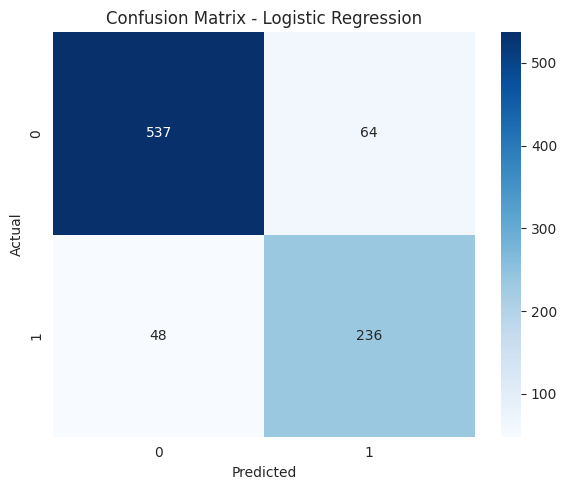

In [12]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/confusion_matrix_logreg.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. ROC Curve

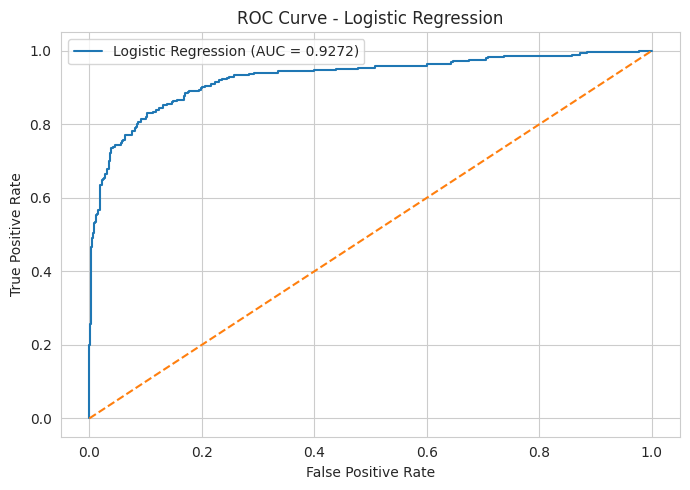

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/figures/roc_curve_logreg.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Koefisien / feature importance versi Logistic Regression

In [14]:
model = logreg_pipeline.named_steps['model']
coef = model.coef_[0]

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': coef,
    'abs_coefficient': np.abs(coef)
}).sort_values('abs_coefficient', ascending=False)

display(coef_df.head(20))

,feature,coefficient,abs_coefficient
30,Curricular units 2nd sem (approved),-1.826410,1.826410
24,Curricular units 1st sem (approved),-0.923216,0.923216
28,Curricular units 2nd sem (enrolled),0.823570,0.823570
16,Tuition fees up to date,-0.718815,0.718815
27,Curricular units 2nd sem (credited),0.505580,0.505580
20,International,-0.352583,0.352583
10,Mother's occupation,-0.341461,0.341461
19,Age at enrollment,0.340985,0.340985
7,Nacionality,0.296051,0.296051
31,Curricular units 2nd sem (grade),-0.293876,0.293876


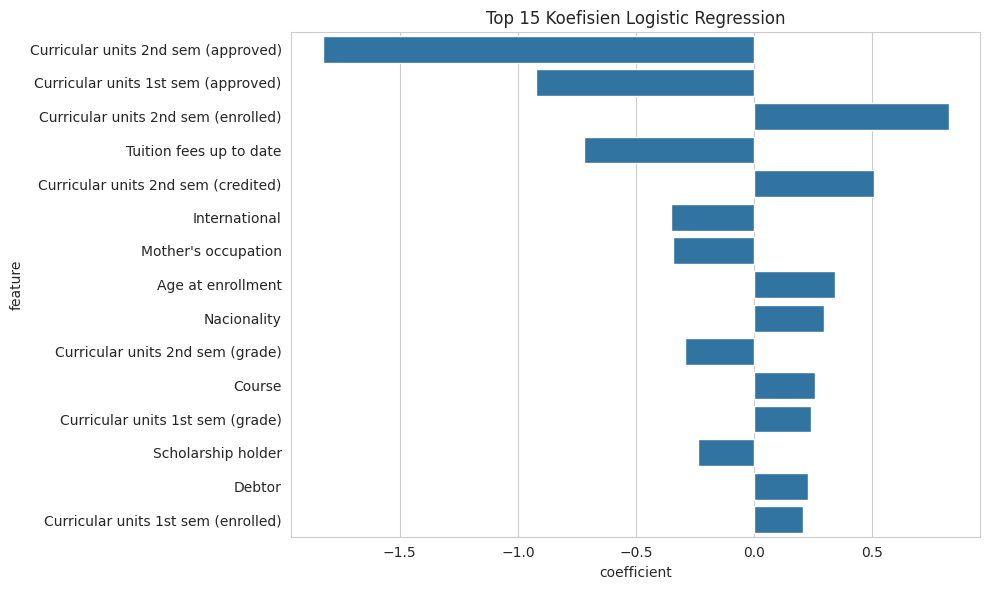

In [15]:
top_coef = coef_df.head(15).copy()

plt.figure(figsize=(10,6))
sns.barplot(data=top_coef, x='coefficient', y='feature')
plt.title('Top 15 Koefisien Logistic Regression')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/feature_importance_logreg.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Simpan model, preprocessor, dan metrics

In [16]:
joblib.dump(logreg_pipeline, '/kaggle/working/models/logistic_regression_pipeline.pkl')
joblib.dump(logreg_pipeline.named_steps['preprocessor'], '/kaggle/working/models/preprocessor_logreg.pkl')

metrics_to_save = metrics.copy()
metrics_to_save['confusion_matrix'] = cm.tolist()
metrics_to_save['classification_report'] = classification_report(y_test, y_pred, output_dict=True)

with open('/kaggle/working/models/model_metrics_logreg.json', 'w') as f:
    json.dump(metrics_to_save, f, indent=4)

print('File berhasil disimpan:')
print('- /kaggle/working/models/logistic_regression_pipeline.pkl')
print('- /kaggle/working/models/preprocessor_logreg.pkl')
print('- /kaggle/working/models/model_metrics_logreg.json')

File berhasil disimpan:
- /kaggle/working/models/logistic_regression_pipeline.pkl
- /kaggle/working/models/preprocessor_logreg.pkl
- /kaggle/working/models/model_metrics_logreg.json


## 11. Ringkasan hasil

In [17]:
print('=== HASIL LOGISTIC REGRESSION ===')
for k, v in metrics.items():
    if k != 'model_name':
        print(f'{k}: {v:.4f}')
    else:
        print(f'{k}: {v}')

=== HASIL LOGISTIC REGRESSION ===
model_name: Logistic Regression
accuracy: 0.8734
precision: 0.7867
recall: 0.8310
f1_score: 0.8082
roc_auc: 0.9272
